In [1]:

from pathlib import Path
import random
from collections import defaultdict
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from pollen_worker.pollen_utils import get_clients_population_dict
from pollen_worker.placements import _pollen_function, get_pollen_models, _predict_single_client, _linear, add_n_batches_column_to_clients_stats_table

# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# poetry shell
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha

In [2]:
colors = {
    'Pollen': 'tab:blue',
    'Round-Robin': 'tab:orange',
    'Batches': 'tab:green',
    'Linear (Parrot)': 'tab:red',
}
colors_devices = {
    'ngongotaha.cl.cam.ac.uk_cuda:0': 'tab:blue',
    'ngongotaha.cl.cam.ac.uk_cuda:1': 'tab:orange',
    'ngongotaha.cl.cam.ac.uk_cuda:2': 'tab:green',
    'mauao.cl.cam.ac.uk_cuda:0': 'tab:red',
}

In [3]:
batch_sizes = {
    'openimage': 20,
    'google_speech': 20,
    'shakespeare_memory': 10,
    'reddit': 20,
}
datasets_list = ['openimage', 'google_speech', 'shakespeare_memory', 'reddit']
# datasets_list = ['shakespeare_memory', 'reddit']

In [4]:
n_workers = {
    'openimage': {
        'ngongotaha.cl.cam.ac.uk': 4,
        'mauao.cl.cam.ac.uk': 14,
    },
    'google_speech': {
        'ngongotaha.cl.cam.ac.uk': 7,
        'mauao.cl.cam.ac.uk': 21,
    },
    'shakespeare_memory': {
        'ngongotaha.cl.cam.ac.uk': 10,
        'mauao.cl.cam.ac.uk': 33,
    },
    'reddit': {
        'ngongotaha.cl.cam.ac.uk': 3,
        'mauao.cl.cam.ac.uk': 14,
    },
}

In [5]:
cid_samples_dicts = {}
for dataset in datasets_list:
    print(dataset)
    cid_samples_dicts[dataset] = get_clients_population_dict(
        name=dataset,
        batch_size=batch_sizes[dataset],
        seed=1337
    )

DEBUG flwr 2023-10-20 17:01:23,818 | pollen_utils.py:294 | Length of cids list before filtering 11325
DEBUG flwr 2023-10-20 17:01:23,821 | pollen_utils.py:296 | Length of cids list after filtering 11325
DEBUG flwr 2023-10-20 17:01:23,833 | pollen_utils.py:298 | Randomly sampled clients with state 1337


openimage
google_speech


DEBUG flwr 2023-10-20 17:01:23,861 | pollen_utils.py:294 | Length of cids list before filtering 2167
DEBUG flwr 2023-10-20 17:01:23,863 | pollen_utils.py:296 | Length of cids list after filtering 2109
DEBUG flwr 2023-10-20 17:01:23,867 | pollen_utils.py:298 | Randomly sampled clients with state 1337
DEBUG flwr 2023-10-20 17:01:23,878 | pollen_utils.py:294 | Length of cids list before filtering 648
DEBUG flwr 2023-10-20 17:01:23,879 | pollen_utils.py:296 | Length of cids list after filtering 380
DEBUG flwr 2023-10-20 17:01:23,881 | pollen_utils.py:298 | Randomly sampled clients with state 1337


shakespeare_memory
reddit


DEBUG flwr 2023-10-20 17:01:24,189 | pollen_utils.py:294 | Length of cids list before filtering 1628176
DEBUG flwr 2023-10-20 17:01:24,206 | pollen_utils.py:296 | Length of cids list after filtering 467705
DEBUG flwr 2023-10-20 17:01:24,233 | pollen_utils.py:298 | Randomly sampled clients with state 1337


In [13]:
ctt_rr_paths = {
    'openimage': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/06-40-05/clients_training_stats.parquet'),
    'google_speech': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/12-15-54/clients_training_stats.parquet'),
    'shakespeare_memory': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-13/23-57-22/clients_training_stats.parquet'),
    'reddit': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/10-33-06/clients_training_stats.parquet'),
}
ctt_rr_scale1_paths = {
    'openimage': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/14-24-58/clients_training_stats.parquet'),
    'google_speech': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/11-27-22/clients_training_stats.parquet'),
    'shakespeare_memory': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/10-12-51/clients_training_stats.parquet'),
    'reddit': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/12-44-48/clients_training_stats.parquet'),
}
ctt_rr_scale2_paths = {
    'openimage': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/14-45-45/clients_training_stats.parquet'),
    'google_speech': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/11-54-56/clients_training_stats.parquet'),
    'shakespeare_memory': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/10-26-37/clients_training_stats.parquet'),
    'reddit': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-20/12-44-48/clients_training_stats.parquet'),
}

ctt_lb_paths = {
    'openimage': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/06-03-50/clients_training_stats.parquet'),
    'google_speech': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-18/02-35-50/clients_training_stats.parquet'),
    'shakespeare_memory': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-13/23-47-21/clients_training_stats.parquet'),
    'reddit': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/09-26-36/clients_training_stats.parquet'),
}
ctt_llb_paths = {
    'openimage': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/06-22-13/clients_training_stats.parquet'),
    'google_speech': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/11-45-37/clients_training_stats.parquet'),
    'shakespeare_memory': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-13/23-52-25/clients_training_stats.parquet'),
    'reddit': Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/09-59-56/clients_training_stats.parquet'),
}
# TODO: Check this data. We want to see the logarithmic behaviour. Produce data with lower workers per cpu cores.
ctt_real_paths = {
    'openimage': [Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-16/09-22-31/clients_training_stats.parquet'), Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-17/15-58-23/clients_training_stats.parquet')],
    'google_speech': [Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-16/16-46-25/clients_training_stats.parquet') , Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-17/19-34-05/clients_training_stats.parquet')],
    'shakespeare_memory': [Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-14/20-53-50/clients_training_stats.parquet'), Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-17/15-58-18/clients_training_stats.parquet')],
    'reddit': [Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-17/01-49-13/clients_training_stats.parquet'), Path('/nfs-share/ls985/pollen_worker/outputs/2023-10-17/16-58-31/clients_training_stats.parquet')],
}

In [20]:
ctt_dfs = {}
for dataset in datasets_list:
    # df = pq.read_table(ctt_rr_paths[dataset])
    # df = pq.read_table(ctt_rr_scale1_paths[dataset])
    df = pq.read_table(ctt_rr_scale2_paths[dataset])
    # df = pq.read_table(ctt_lb_paths[dataset])
    # df = pq.read_table(ctt_llb_paths[dataset])
    # df = pa.concat_tables([pq.read_table(t) for t in ctt_real_paths[dataset]])
    ctt_dfs[dataset] = df

In [21]:
# Compute mean and std per dataset per device per num batches to be used in the MC for the real load
ctt_real_distributions = {}
for dataset in datasets_list:
    ctt_real_distributions[dataset] = {}
    for device in colors_devices.keys():
        try:
            ctt_real_distributions[dataset][device] = {}
            node_name = device.split('_')[0]
            gpu_name = device.split('_')[1]
            tmp_df = ctt_dfs[dataset].filter(pc.field("node") == pc.scalar(node_name)).filter(pc.field("gpu") == pc.scalar(gpu_name))
            tmp_df = add_n_batches_column_to_clients_stats_table(tmp_df, batch_sizes[dataset], cid_samples_dicts[dataset])
            unique_batches = sorted(np.unique(tmp_df.column("n_batches").to_numpy()))
            for b in unique_batches:
                tmp_df_b = tmp_df.filter(pc.field("n_batches") == pc.scalar(b))
                y1 = tmp_df_b.column("end_time").to_numpy()
                y0 = tmp_df_b.column("start_time").to_numpy()
                delta = (y1 - y0) * 1e-9
                ctt_real_distributions[dataset][device][b] = {
                    'mean': delta.mean(),
                    'std': delta.std(),
                }
        except Exception as e:
            print(dataset, device, e)

In [22]:
ctt_real_distributions

{'openimage': {'ngongotaha.cl.cam.ac.uk_cuda:0': {1: {'mean': 0.8896836408366418,
    'std': 0.2181580193240763},
   2: {'mean': 1.0165803775594615, 'std': 0.2691822803828949},
   3: {'mean': 1.1227789275276383, 'std': 0.16109525628028673},
   4: {'mean': 1.2630059303564356, 'std': 0.46135817596720585},
   5: {'mean': 1.3399534804931132, 'std': 0.1931766155058933},
   6: {'mean': 1.4731672408165941, 'std': 0.20971715416955572},
   7: {'mean': 1.5836732151832464, 'std': 0.21300287777902827},
   8: {'mean': 1.7420474945096776, 'std': 0.29163900482772376},
   9: {'mean': 1.8403092301633988, 'std': 0.3291689839238759},
   10: {'mean': 1.927363301747573, 'std': 0.3240602856662823},
   11: {'mean': 2.003253509481013, 'std': 0.3244598191332267},
   12: {'mean': 2.135626007935484, 'std': 0.28405273172814627},
   13: {'mean': 2.2706883067, 'std': 0.25826336280014084},
   14: {'mean': 2.4401075090000006, 'std': 0.3276779079525951},
   15: {'mean': 2.497016078170213, 'std': 0.3482932208385359},
 

In [23]:
pollen_models = {}
for dataset in datasets_list:
    pollen_models[dataset] = get_pollen_models(cid_samples_dicts[dataset], 'lb', batch_sizes[dataset], ctt_dfs[dataset])
print(pollen_models)
linear_models = {}
for dataset in datasets_list:
    linear_models[dataset] = get_pollen_models(cid_samples_dicts[dataset], 'llb', batch_sizes[dataset], ctt_dfs[dataset])
print(linear_models)

DEBUG flwr 2023-10-20 17:26:07,441 | placements.py:185 | Pollen-MLStrategy :: models' scores {'ngongotaha.cl.cam.ac.uk_cuda:0': 1286.74420417162, 'ngongotaha.cl.cam.ac.uk_cuda:2': 1271.4412352593022, 'ngongotaha.cl.cam.ac.uk_cuda:1': 1202.4678249564065, 'mauao.cl.cam.ac.uk_cuda:0': 14822.655517723102}
DEBUG flwr 2023-10-20 17:26:07,661 | placements.py:185 | Pollen-MLStrategy :: models' scores {'mauao.cl.cam.ac.uk_cuda:0': 5449.8120757228335, 'ngongotaha.cl.cam.ac.uk_cuda:1': 2477.98089746656, 'ngongotaha.cl.cam.ac.uk_cuda:2': 2464.9005537607186, 'ngongotaha.cl.cam.ac.uk_cuda:0': 2418.1496211955164}


DEBUG flwr 2023-10-20 17:26:08,359 | placements.py:185 | Pollen-MLStrategy :: models' scores {'ngongotaha.cl.cam.ac.uk_cuda:0': 0.12020954378671618, 'ngongotaha.cl.cam.ac.uk_cuda:2': 1384.037304221931, 'ngongotaha.cl.cam.ac.uk_cuda:1': 7.349486022569964, 'mauao.cl.cam.ac.uk_cuda:0': 6677.811770368486}
DEBUG flwr 2023-10-20 17:26:08,488 | placements.py:185 | Pollen-MLStrategy :: models' scores {'ngongotaha.cl.cam.ac.uk_cuda:1': 209.52263059733323, 'ngongotaha.cl.cam.ac.uk_cuda:0': 213.51253486963998, 'ngongotaha.cl.cam.ac.uk_cuda:2': 210.15282504766492, 'mauao.cl.cam.ac.uk_cuda:0': 3792.624865807289}


{'openimage': {'ngongotaha.cl.cam.ac.uk_cuda:0': (array([0.77255666, 0.02945198, 0.1083488 ]), array([[ 1.31384812e-05, -8.37338603e-06,  2.51239042e-07],
       [-8.37338603e-06,  1.65130746e-05, -1.41046350e-06],
       [ 2.51239042e-07, -1.41046350e-06,  2.29875001e-07]])), 'ngongotaha.cl.cam.ac.uk_cuda:2': (array([0.76505762, 0.00335623, 0.11279676]), array([[ 1.29257120e-05, -8.54251637e-06,  3.06924282e-07],
       [-8.54251637e-06,  1.80226138e-05, -1.72592147e-06],
       [ 3.06924282e-07, -1.72592147e-06,  2.84369803e-07]])), 'ngongotaha.cl.cam.ac.uk_cuda:1': (array([0.75473737, 0.01542516, 0.11272539]), array([[ 1.18132510e-05, -7.90995964e-06,  2.99338143e-07],
       [-7.90995964e-06,  1.75349417e-05, -1.80870670e-06],
       [ 2.99338143e-07, -1.80870670e-06,  3.08417841e-07]])), 'mauao.cl.cam.ac.uk_cuda:0': (array([2.04021345, 0.12972765, 0.10746551]), array([[ 3.65404876e-05, -2.39519316e-05,  8.03846923e-07],
       [-2.39519316e-05,  5.16520624e-05, -4.79719334e-06],
 

DEBUG flwr 2023-10-20 17:26:08,753 | placements.py:185 | Pollen-MLStrategy :: models' scores {'ngongotaha.cl.cam.ac.uk_cuda:0': 1289.8021928804758, 'ngongotaha.cl.cam.ac.uk_cuda:2': 1271.1079863707885, 'ngongotaha.cl.cam.ac.uk_cuda:1': 1201.029940413883, 'mauao.cl.cam.ac.uk_cuda:0': 14918.399494082276}
DEBUG flwr 2023-10-20 17:26:08,914 | placements.py:185 | Pollen-MLStrategy :: models' scores {'mauao.cl.cam.ac.uk_cuda:0': 5449.52324644521, 'ngongotaha.cl.cam.ac.uk_cuda:1': 2476.962307199884, 'ngongotaha.cl.cam.ac.uk_cuda:0': 2418.1453211164203, 'ngongotaha.cl.cam.ac.uk_cuda:2': 2465.1506064655637}
DEBUG flwr 2023-10-20 17:26:09,317 | placements.py:185 | Pollen-MLStrategy :: models' scores {'ngongotaha.cl.cam.ac.uk_cuda:0': 0.11909807324967388, 'ngongotaha.cl.cam.ac.uk_cuda:2': 1384.0169073426468, 'ngongotaha.cl.cam.ac.uk_cuda:1': 7.349042209015913, 'mauao.cl.cam.ac.uk_cuda:0': 6723.657055878661}
DEBUG flwr 2023-10-20 17:26:09,418 | placements.py:185 | Pollen-MLStrategy :: models' scor

{'openimage': {'ngongotaha.cl.cam.ac.uk_cuda:0': (array([0.78623638, 0.11119128]), array([[ 9.04794860e-06, -4.92755219e-07],
       [-4.92755219e-07,  1.17013527e-07]])), 'ngongotaha.cl.cam.ac.uk_cuda:2': (array([0.76647623, 0.11316674]), array([[ 8.86624977e-06, -5.09028084e-07],
       [-5.09028084e-07,  1.18562680e-07]])), 'ngongotaha.cl.cam.ac.uk_cuda:1': (array([0.75876801, 0.11509972]), array([[ 8.28586104e-06, -5.26499547e-07],
       [-5.26499547e-07,  1.24501835e-07]])), 'mauao.cl.cam.ac.uk_cuda:0': (array([2.09399076, 0.12111296]), array([[ 2.63705181e-05, -1.56939775e-06],
       [-1.56939775e-06,  3.77306664e-07]]))}, 'google_speech': {'mauao.cl.cam.ac.uk_cuda:0': (array([2.96085871, 0.38815223]), array([[ 6.33777640e-05, -1.77987354e-05],
       [-1.77987354e-05,  9.55165975e-06]])), 'ngongotaha.cl.cam.ac.uk_cuda:1': (array([3.84291965, 0.87221194]), array([[ 3.72195788e-04, -1.13488031e-04],
       [-1.13488031e-04,  6.44062078e-05]])), 'ngongotaha.cl.cam.ac.uk_cuda:0': 

In [27]:
for dataset in datasets_list:
    plt.figure(figsize=(10, 5))
    x = np.linspace(1,max([v for k,v in cid_samples_dicts[dataset].items()])//batch_sizes[dataset],250)
    max_y_axis = 0
    for k,v in pollen_models[dataset].items():
        # if 'mauao' in k:
        node_name = k.split('_')[0]
        gpu_name = k.split('_')[1]
        tmp_df = ctt_dfs[dataset].filter(pc.field("node") == pc.scalar(node_name)).filter(pc.field("gpu") == pc.scalar(gpu_name))
        tmp_df = add_n_batches_column_to_clients_stats_table(tmp_df, batch_sizes[dataset], cid_samples_dicts[dataset])
        x_data = tmp_df.column("n_batches").to_numpy()
        # x_data = tmp_df.column("n_samples").to_numpy()
        y1_data = tmp_df.column("end_time").to_numpy()
        y0_data = tmp_df.column("start_time").to_numpy()
        plt.scatter(x_data, (y1_data-y0_data) * 1e-9, label=f"Data - {k}", alpha=0.3, c=colors_devices[k], marker=".")
        plt.plot(x, _pollen_function(x,*v[0]), label=f"Fit curve - {k}", c=colors_devices[k])
        max_y_axis = max(max_y_axis, max(_pollen_function(x,*v[0])))
    plt.ylim(top=max_y_axis*1.1)
    # plt.ylim(top=20*1.1)
    # plt.xlim(right=50*1.1)
    plt.ylabel("Time [s]")
    plt.xlabel("Number of batches")
    plt.legend()
    plt.title(f"{dataset.upper()} - clients training time")
    plt.grid()

KeyError: 'Field "n_samples" does not exist in schema'

<Figure size 1000x500 with 0 Axes>

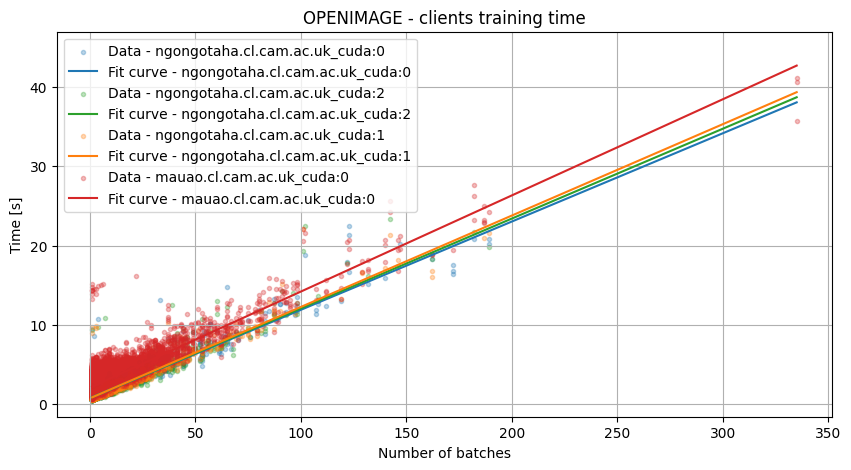

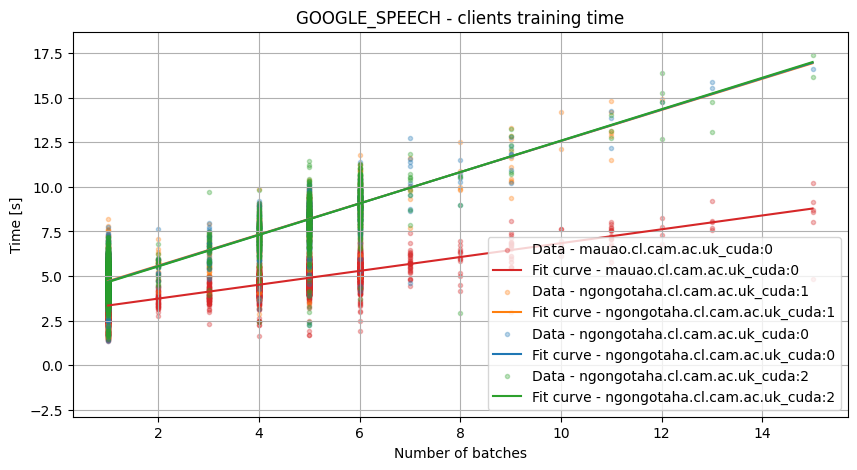

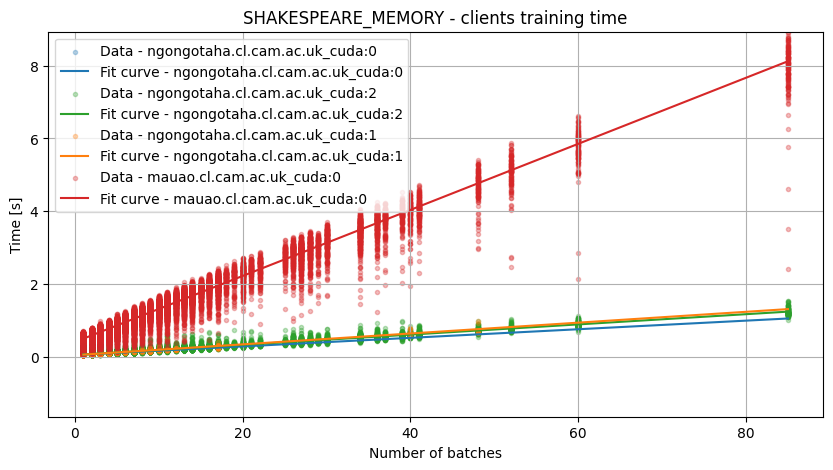

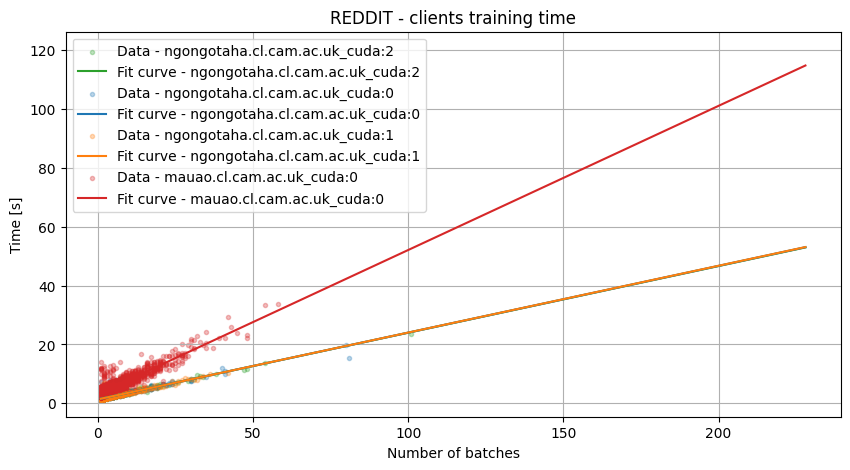

In [25]:
for dataset in datasets_list:
    plt.figure(figsize=(10, 5))
    x = np.linspace(1,max([v for k,v in cid_samples_dicts[dataset].items()])//batch_sizes[dataset],250)
    max_y_axis = 0.0
    for k,v in linear_models[dataset].items():
        node_name = k.split('_')[0]
        gpu_name = k.split('_')[1]
        tmp_df = ctt_dfs[dataset].filter(pc.field("node") == pc.scalar(node_name)).filter(pc.field("gpu") == pc.scalar(gpu_name))
        tmp_df = add_n_batches_column_to_clients_stats_table(tmp_df, batch_sizes[dataset], cid_samples_dicts[dataset])
        x_data = tmp_df.column("n_batches").to_numpy()
        y1_data = tmp_df.column("end_time").to_numpy()
        y0_data = tmp_df.column("start_time").to_numpy()
        plt.scatter(x_data, (y1_data-y0_data) * 1e-9, label=f"Data - {k}", alpha=0.3, c=colors_devices[k], marker=".")
        plt.plot(x, _linear(x,*v[0]), label=f"Fit curve - {k}", c=colors_devices[k])
        max_y_axis = max(max_y_axis, max(_linear(x,*v[0])))
    plt.ylim(top=max_y_axis*1.1)
    plt.ylabel("Time [s]")
    plt.xlabel("Number of batches")
    plt.legend()
    plt.title(f"{dataset.upper()} - clients training time")
    plt.grid()

In [26]:
def create_rr_splits(cids, n_total_workers):
    return np.array_split(cids, n_total_workers)

In [14]:
def create_batches_splits(cids, cid_samples_dict, n_total_workers, batch_size):
    cids = sorted(
        cids,
        key=lambda x: cid_samples_dict[x],
        reverse=True,
    )
    tmp_splits = [[c] for c in cids[:n_total_workers]]
    for virtual_cid in cids[n_total_workers:]:
        sums = [
            sum([(cid_samples_dict[x] // batch_size) for x in list_cids])
            for list_cids in tmp_splits
        ]
        min_worker = np.argmin(sums)
        tmp_splits[min_worker].append(virtual_cid)
    return [np.array([x for x in list_cids]) for list_cids in tmp_splits]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

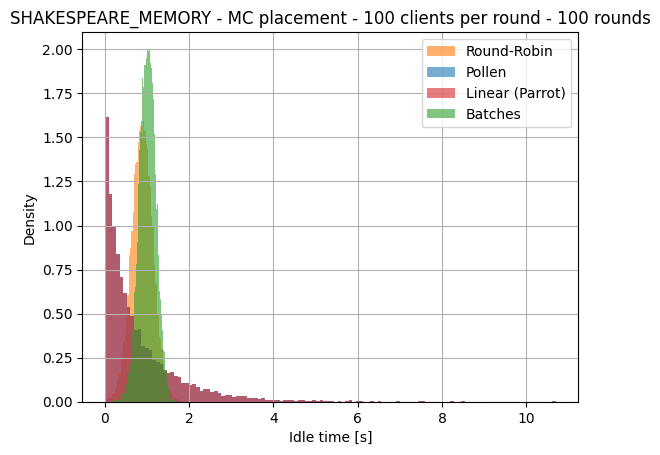

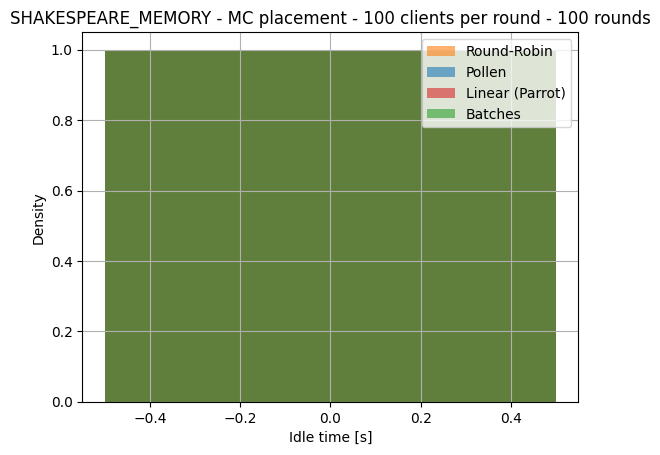

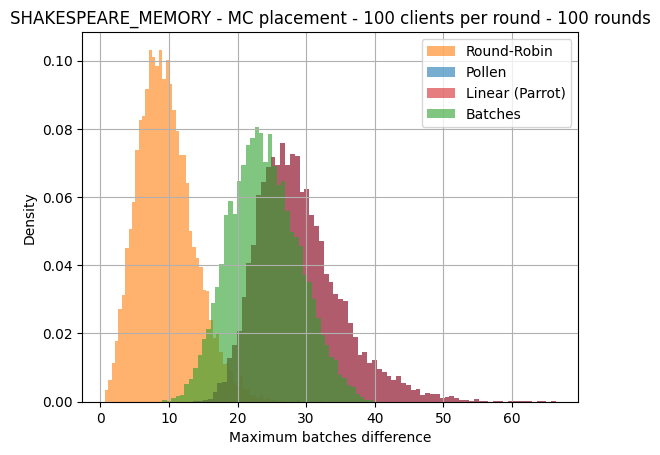

In [15]:
# Loop over datasets
for dataset in datasets_list:
    # Set number of clients per round
    n_clients_per_round = 100
    # Set the number of rounds
    n_rounds = 100
    # Loop over seeds
    repetitions = 100
    max_real_idle_time = defaultdict(list)
    max_estimated_idle_time = defaultdict(list)
    max_batches_difference = defaultdict(list)
    # TODO: Add the optimum placement with forward knowledge using the real load
    for policy in ['Round-Robin', 'Pollen', 'Linear (Parrot)', 'Batches']:
        # Set global seed
        random.seed(1337)
        for rep in tqdm(range(repetitions)):
            # Set repetition's seed
            seed = random.randint(0, 2**32 - 1)
            x_train_data = []
            y_train_data = []
            device_id_train_data = []
            # Loop over rounds
            for i in range(n_rounds):
                # Init assignment
                devices_assignments = {
                    k: [
                        0.0, # Real load
                        0.0, # Device load
                        0, # Sum of batches
                        k.split("_")[0],  # Node name
                        k.split("_")[1],  # Device name
                        n_workers[dataset][str(k)[:-7]],  # Device concurrency
                    ]
                    for k, v in pollen_models[dataset].items()
                }
                # Sample clients
                if n_clients_per_round > len(cid_samples_dicts[dataset]):
                    # Generate random selection of virtual clients (number of virtual clients per round)
                    cids = random.choices(list(cid_samples_dicts[dataset]), k=n_clients_per_round)  # type: ignore
                else:
                    # Generate random selection of virtual clients (number of virtual clients per round)
                    cids = random.sample(list(cid_samples_dicts[dataset]), k=n_clients_per_round)  # type: ignore
                # Get clients' splits
                n_total_workers = np.sum(
                    [
                        n_workers[dataset][str(k)[:-7]]
                        for k,v in pollen_models[dataset].items()
                    ]
                )
                if policy == 'Round-Robin':
                    splits = create_rr_splits(cids, n_total_workers)
                elif policy == 'Batches':
                    splits = create_batches_splits(cids, cid_samples_dicts[dataset], n_total_workers, batch_sizes[dataset])
                if policy == 'Batches' or policy == 'Round-Robin':
                    # Assign splits
                    while len(splits) > 0:
                        # Loop over devices
                        for device_id, model in pollen_models[dataset].items():
                            for _ in range(devices_assignments[device_id][5]):
                                current_split = splits.pop(0)
                                if len(current_split) > 0:
                                    for c in current_split:
                                        n_batches = cid_samples_dicts[dataset][c] // batch_sizes[dataset]
                                        mean = ctt_real_distributions[dataset][device_id][n_batches]['mean']
                                        std = ctt_real_distributions[dataset][device_id][n_batches]['std']                                            
                                        real_load = random.gauss(mean, std)
                                        x_train_data.append(n_batches)
                                        y_train_data.append(real_load)
                                        device_id_train_data.append(device_id)
                                        devices_assignments[device_id][0] += real_load / devices_assignments[device_id][5]
                                        devices_assignments[device_id][2] += n_batches / devices_assignments[device_id][5]
                elif policy == 'Pollen':
                    while len(cids) > 0:
                        # Extract the first element of the list
                        virtual_cid = cids.pop(0)
                        # Get minimum loaded device
                        sorted_devices_assignments = sorted(devices_assignments.items(), key=lambda x: x[1][0])
                        min_device_key = sorted_devices_assignments[0][0]
                        # Get device load
                        estimated_load = _predict_single_client(
                            model=pollen_models[dataset][min_device_key],
                            fn=_pollen_function,
                            n_samples=cid_samples_dicts[dataset][virtual_cid],
                            batch_size=batch_sizes[dataset],
                        )
                        n_batches = cid_samples_dicts[dataset][virtual_cid] // batch_sizes[dataset]
                        mean = ctt_real_distributions[dataset][min_device_key][n_batches]['mean']
                        std = ctt_real_distributions[dataset][min_device_key][n_batches]['std']
                        real_load = random.gauss(mean, std)
                        x_train_data.append(n_batches)
                        y_train_data.append(real_load)
                        device_id_train_data.append(device_id)
                        devices_assignments[min_device_key][0] += real_load
                        devices_assignments[min_device_key][1] += estimated_load / devices_assignments[min_device_key][5]
                        devices_assignments[min_device_key][2] += n_batches / devices_assignments[min_device_key][5]
                elif policy == 'Linear (Parrot)':
                    while len(cids) > 0:
                        # Extract the first element of the list
                        virtual_cid = cids.pop(0)
                        # Get minimum loaded device
                        sorted_devices_assignments = sorted(devices_assignments.items(), key=lambda x: x[1][0])
                        min_device_key = sorted_devices_assignments[0][0]
                        # Get device load
                        estimated_load = _predict_single_client(
                            model=linear_models[dataset][min_device_key],
                            fn=_linear,
                            n_samples=cid_samples_dicts[dataset][virtual_cid],
                            batch_size=batch_sizes[dataset],
                        )
                        n_batches = cid_samples_dicts[dataset][virtual_cid] // batch_sizes[dataset]
                        mean = ctt_real_distributions[dataset][min_device_key][n_batches]['mean']
                        std = ctt_real_distributions[dataset][min_device_key][n_batches]['std']
                        real_load = random.gauss(mean, std)
                        x_train_data.append(n_batches)
                        y_train_data.append(real_load)
                        device_id_train_data.append(device_id)
                        devices_assignments[min_device_key][0] += real_load
                        devices_assignments[min_device_key][1] += estimated_load / devices_assignments[min_device_key][5]
                        devices_assignments[min_device_key][2] += n_batches / devices_assignments[min_device_key][5]
                # Compute load balancing
                max_batches_difference[policy].append(max([v[2] for k,v in devices_assignments.items()])-min([v[2] for k,v in devices_assignments.items()]))
                sorted_devices_assignments = sorted(devices_assignments.items(), key=lambda x: x[1][0], reverse=True)
                max_real_loaded_device = sorted_devices_assignments[0]
                max_real_load = max_real_loaded_device[1][0]
                second_max_real_loaded_device = sorted_devices_assignments[1]
                second_max_real_load = second_max_real_loaded_device[1][0]
                max_real_idle_time[policy].append(max_real_load-second_max_real_load)
                sorted_devices_assignments = sorted(devices_assignments.items(), key=lambda x: x[1][1], reverse=True)
                max_estimated_loaded_device = sorted_devices_assignments[1]
                max_estimated_load = max_estimated_loaded_device[1][1]
                second_max_estimated_loaded_device = sorted_devices_assignments[1]
                second_max_estimated_load = second_max_estimated_loaded_device[1][1]
                max_estimated_idle_time[policy].append(max_estimated_load-second_max_estimated_load)
    # Plot results
    for k,v in max_real_idle_time.items():
        plt.hist(max_real_idle_time[k], bins='auto', label=k, density=True, color=colors[k], alpha=0.6)
    plt.ylabel("Density")
    plt.xlabel("Idle time [s]")
    plt.title(f"{dataset.upper()} - MC placement - {n_clients_per_round} clients per round - {n_rounds} rounds")
    plt.legend()
    plt.grid()
    plt.savefig(f"MC_real_idletime_{dataset}_{n_clients_per_round}_{n_rounds}.pdf", format="pdf", dpi=800, bbox_inches='tight')
    plt.show()
    for k,v in max_estimated_idle_time.items():
        plt.hist(max_estimated_idle_time[k], bins='auto', label=k, density=True, color=colors[k], alpha=0.6)
    plt.ylabel("Density")
    plt.xlabel("Idle time [s]")
    plt.title(f"{dataset.upper()} - MC placement - {n_clients_per_round} clients per round - {n_rounds} rounds")
    plt.legend()
    plt.grid()
    plt.savefig(f"MC_estimated_idletime_{dataset}_{n_clients_per_round}_{n_rounds}.pdf", format="pdf", dpi=800, bbox_inches='tight')
    plt.show()
    for k,v in max_real_idle_time.items():
        plt.hist(max_batches_difference[k], bins='auto', label=k, density=True, color=colors[k], alpha=0.6)
    plt.title(f"{dataset.upper()} - MC placement - {n_clients_per_round} clients per round - {n_rounds} rounds")
    plt.ylabel("Density")
    plt.xlabel("Maximum batches difference")
    plt.legend()
    plt.grid()
    plt.savefig(f"MC_batches_{dataset}_{n_clients_per_round}_{n_rounds}.pdf", format="pdf", dpi=800, bbox_inches='tight')
    plt.show()